In [1]:
%load_ext autoreload
%autoreload 2

In [8]:

from mad.objs.planets import Planet, PlanetConfig
from mad.objs import Radar, RadarConfig

from mad.configs.planets import EARTH_SETTINGS

In [18]:
EARTH_SETTINGS["radius"] = 100.0

earth = Planet(PlanetConfig(**EARTH_SETTINGS))

random_pos = earth.create_2D_point(altitude=5.0)
target1 = earth.create_2D_point_at_distance(random_pos, distance_km=0.02, name="Target1")
target2 = earth.create_2D_point_at_distance(random_pos, distance_km=0.2, name="Target2")

radar_cfg = RadarConfig(
    position = random_pos.position,
    range=45.0,
    name="TestRadar",
    voxel_size=9
)

radar = Radar(radar_cfg, earth)

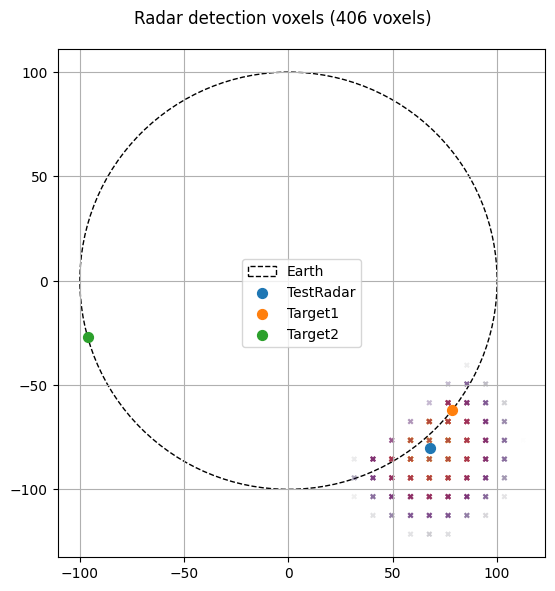

In [19]:
fig, ax = plt.subplots(figsize=(6, 6))
earth.plot_2D_with_points([radar, target1, target2], display="planet", ax=ax)

# Convert voxel grid keys to world-space voxel centres for plotting
voxel_keys = np.array(list(radar.detection_voxels.keys()))
voxel_centers = (voxel_keys + 0.5) * radar.voxel_size
detection_strength = list(radar.detection_voxels.values())

ax.scatter(voxel_centers[:, 0], voxel_centers[:, 1], 
           c=detection_strength, marker='x', s=10, cmap="inferno",
           alpha=detection_strength)
ax.legend()
fig.suptitle(f"Radar detection voxels ({len(radar.detection_voxels)} voxels)")
fig.tight_layout(pad=1.2)

In [20]:
radar.detect(target1), radar.detect(target2)

(True, False)

In [21]:
radar.get_detection_strength(radar), radar.get_detection_strength(target1), radar.get_detection_strength(target2)

(0.8723331845583395, 0.4754090081702844, 0.0)